The following cells is going to be me working through Chapter 3 of the Hands-On Machine Learning book. Classification

Section: MNIST

In [1]:
from sklearn.datasets import fetch_openml

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#Fetching the MNIST dataset from OpenML
mnist = fetch_openml('mnist_784', version = 1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [3]:
#Getting the data and target values. There are 70000 images of handwritten digits. 
X, y = mnist['data'], mnist['target']

#The 784 features are the pixel values of the images. Each image is 28x28
print("Shape of X: ", X.shape)
print("Shape of y: ", y.shape)

Shape of X:  (70000, 784)
Shape of y:  (70000,)


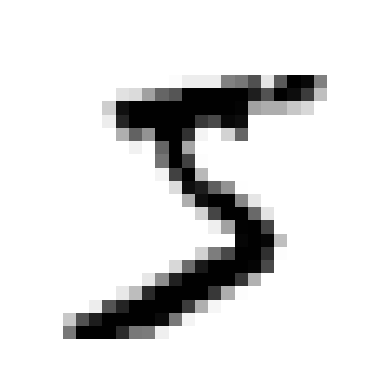

Label:  5


In [4]:
#Getting the first digit image
some_digit = X.iloc[0].to_numpy()
some_digit_image = some_digit.reshape(28, 28)

plt.imshow(some_digit_image, cmap = mpl.cm.binary, interpolation = 'nearest')
plt.axis('off')
plt.show()

print("Label: ", y.iloc[0])
y = y.astype(np.uint8)

In [5]:
#Creating the training and test sets
X_train, X_test, y_train, y_test = X.iloc[:60000], X.iloc[60000:], y.iloc[:60000], y.iloc[60000:]

Training a Binary Classifier

In [6]:
#Using a Stochastic Gradient Descent classifier to determine whether a digit is 5 or not
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)


In [7]:
#Training the SGD Classifier
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state = 42)
sgd_clf.fit(X_train, y_train_5)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

In [8]:
sgd_clf.predict([some_digit])

/Users/richardlui/School/CMPT455/Experiments/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([ True])

Measuring Accuracy using Cross-Validation

In [9]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv = 3, scoring = 'accuracy')

array([0.95035, 0.96035, 0.9604 ])

In [10]:
#Since only 10 percent of the images are 5s, we can create a dummy classsifier that will predict whether or not a digit is 5

from sklearn.base import BaseEstimator

class Never5Classifier(BaseEstimator):
    def fit(self, X, y = None):
        pass
    def predict(self, X):
        return np.zeros((len(X), 1), dtype = bool)

never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, X_train, y_train_5, cv = 3, scoring = 'accuracy')

array([0.91125, 0.90855, 0.90915])

Confusion Matrix

In [11]:
#Using a Confusion Matrix to represent the results of the Classification

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

#The first row is with regards to Non5's, and the second row is with regards to 5's
#The diagonal columns have to do with correct predictions, and the off-diagonals are incorrect predictions
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv = 3)
conf_matrix = confusion_matrix(y_train_5, y_train_pred)
print(conf_matrix)

[[53892   687]
 [ 1891  3530]]


Precision and Recall

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Precision = TP / (TP + FP)
precision = precision_score(y_train_5, y_train_pred)
raw_precision = conf_matrix[1, 1] / sum(conf_matrix[:, 1])

print("The precision is the ratio of True Positive to the sum of Positive Predicitions: ", raw_precision)
print("Precision Score: ", precision)

#Recall = TP / (TP + FN)
recall = recall_score(y_train_5, y_train_pred)
raw_recall = conf_matrix[1, 1] / sum(conf_matrix[1, :])

print("The recall is the ration of True Positives to the sum of Actual Positive Values: ", raw_recall)
print("Recall Score: ", recall)

#F1 Score = 2 / ((1 / precision) + (1 / recall))
f1_score = 2 / ((1 / precision) + (1 / recall))
print("F1 Score: ", f1_score)

The precision is the ratio of True Positive to the sum of Positive Predicitions:  0.8370879772350012
Precision Score:  0.8370879772350012
The recall is the ration of True Positives to the sum of Actual Positive Values:  0.6511713705958311
Recall Score:  0.6511713705958311
F1 Score:  0.7325171197343847


Precision/Recalll Tradeoff

In [13]:
#Since the SGD classifier makes it diagnoses based on a threshold, if you raise the threshold, FN+ while TP-. This increases Precision while decreasing Recall
y_scores = sgd_clf.decision_function([some_digit])

print("Some Digit Y Score: ", y_scores)
#Looking at the classification if I change the threshold
y_some_digit_0 = (y_scores > 0)
y_some_digit_8000 = (y_scores > 8000)

print("Current SGD Threshold: ", y_some_digit_0)
print("8000 SGD Threshold: ", y_some_digit_8000)


Some Digit Y Score:  [2164.22030239]
Current SGD Threshold:  [ True]
8000 SGD Threshold:  [False]


/Users/richardlui/School/CMPT455/Experiments/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


In [20]:
#I want to run the classifier, but to return the decision function. I will get the different thresholds and calculate precision and recall
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv = 3, method = 'decision_function')

from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)  

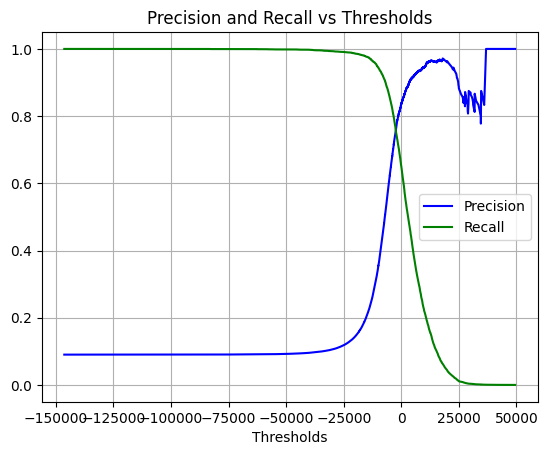

In [21]:
#Next I will generate the precision and recall curves versus threshold

def plot_precision_and_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], color = 'blue', label = 'Precision')
    plt.plot(thresholds, recalls[:-1], color = 'green', label = 'Recall')
    plt.xlabel('Thresholds')
    plt.title('Precision and Recall vs Thresholds')
    plt.grid()
    plt.legend()


plot_precision_and_recall_vs_threshold(precisions, recalls, thresholds)

/var/folders/2n/z9x_tw7s5yg11zzdd5536_7w0000gn/T/ipykernel_24294/3226593557.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


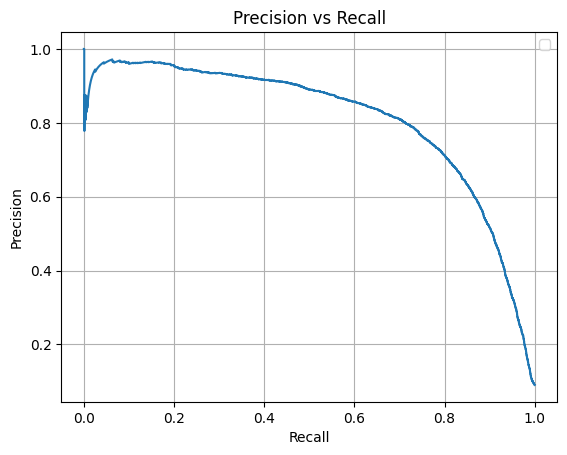

In [23]:
def plot_precision_vs_recall(precisions, recalls):
    plt.title("Precision vs Recall")
    plt.xlabel("Recall")
    plt.ylabel("Precision")

    plt.plot(recalls.flatten(), precisions.flatten())
    plt.grid()
    plt.legend()

plot_precision_vs_recall(precisions, recalls)

The ROC Curve

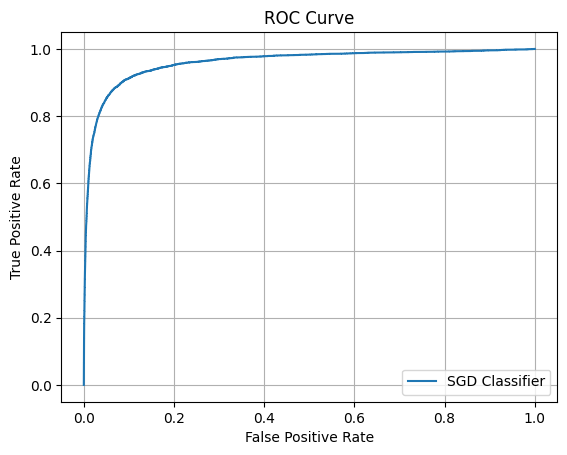

In [24]:
#The ROC Curve models True Positive Rate vs False Positive Rate
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

def plot_roc_curve(fpr, tpr, label = None):
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.plot(fpr, tpr, label = label)
    plt.grid()
    plt.legend()

plot_roc_curve(fpr, tpr, "SGD Classifier")

In [26]:
from sklearn.metrics import roc_auc_score
#The AUC scores calculates the area under the ROC Curve.
#A perfect classifier will have an AUC of 1, and a purely random classifier will have an AUC of 0.5

roc_auc_score(y_train_5, y_scores)


0.9604938554008616

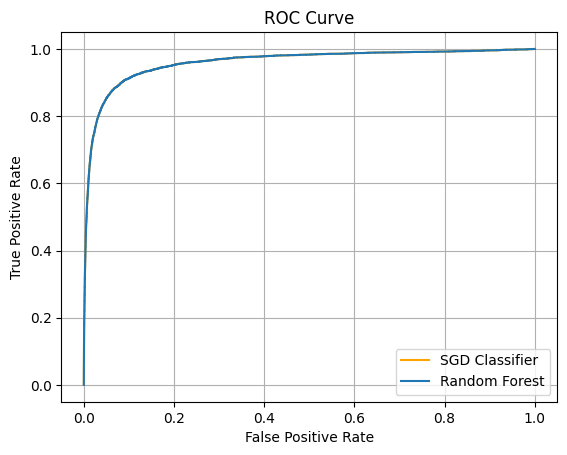

In [31]:
from sklearn.ensemble import RandomForestClassifier
#Now we will train a Random Forest Classifier and Compare it to a Stochastic Gradient Classifier

rf_clf = RandomForestClassifier(random_state = 42)
y_probas_forest = cross_val_predict(rf_clf, X_train, y_train_5, cv = 3, method = 'predict_proba')
y_scores_rf = y_probas_forest[:, 1]
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_5, y_scores)

plt.plot(fpr, tpr, color = 'orange', label = 'SGD Classifier')
plot_roc_curve(fpr_forest, tpr_forest, label = 'Random Forest')

In [34]:
roc_auc_score(y_train_5, y_scores_rf)

0.9983296721818179